In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

In [3]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

master_df = pd.read_csv(
    PROCESSED_DATA / "master_dataset.csv"
)

print("Master dataset shape:", master_df.shape)
display(master_df.head())

Master dataset shape: (3834, 18)


,CustomerID,response,n_comp,loyalty,nps,n_communications,total_sales,unique_products,number_of_invoices,purchase_days,cancelled_invoices,cancellation_value,net_sales,average_order_value,total_invoice_activity,cancellation_rate,nps_category,has_cancellation
0,12346,1,2,1,7.0,8,77183.60,1,1,1,1,77183.60,0.00,77183.600000,2,0.500000,Passive,1
1,12747,0,1,1,3.0,3,3489.74,39,9,9,0,0.00,3489.74,387.748889,9,0.000000,Detractor,0
2,12748,1,0,1,9.0,6,28868.19,1602,175,100,12,4597.18,24271.01,164.961086,187,0.064171,Promoter,1
3,12749,0,4,1,2.0,5,4090.88,160,5,4,3,222.68,3868.20,818.176000,8,0.375000,Detractor,1
4,12820,0,4,1,2.0,2,942.34,55,4,4,0,0.00,942.34,235.585000,4,0.000000,Detractor,0


In [4]:
features = [
    "total_sales",
    "unique_products",
    "number_of_invoices",
    "nps",
    "n_comp",
    "n_communications",
    "loyalty"
]

X = master_df[features].copy()
y = master_df["response"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining response rate:", round(y_train.mean() * 100, 2), "%")
print("Test response rate:", round(y_test.mean() * 100, 2), "%")

Training set: (3067, 7)
Test set: (767, 7)

Training response rate: 40.56 %
Test response rate: 40.55 %


In [5]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=features,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=features,
    index=X_test.index
)

print("Missing values after imputation:")
print("Train:", X_train_imputed.isna().sum().sum())
print("Test:", X_test_imputed.isna().sum().sum())

Missing values after imputation:
Train: 0
Test: 0


In [6]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(
    X_train_imputed,
    y_train
)

print("Gaussian Naive Bayes trained successfully.")

Gaussian Naive Bayes trained successfully.


In [7]:
train_probabilities_nb = (
    naive_bayes_model.predict_proba(
        X_train_imputed
    )[:, 1]
)

test_probabilities_nb = (
    naive_bayes_model.predict_proba(
        X_test_imputed
    )[:, 1]
)

train_auc_nb = roc_auc_score(
    y_train,
    train_probabilities_nb
)

test_auc_nb = roc_auc_score(
    y_test,
    test_probabilities_nb
)

print(
    "Naive Bayes Training ROC AUC:",
    round(train_auc_nb, 4)
)

print(
    "Naive Bayes Test ROC AUC:",
    round(test_auc_nb, 4)
)

Naive Bayes Training ROC AUC: 0.6801
Naive Bayes Test ROC AUC: 0.6551


In [8]:
test_predictions_nb = (
    test_probabilities_nb >= 0.50
).astype(int)

test_confusion_matrix_nb = confusion_matrix(
    y_test,
    test_predictions_nb
)

print("Naive Bayes Test Confusion Matrix:")
print(test_confusion_matrix_nb)

Naive Bayes Test Confusion Matrix:
[[411  45]
 [212  99]]


In [9]:
tn, fp, fn, tp = test_confusion_matrix_nb.ravel()

test_accuracy_nb = (
    (tp + tn) / (tp + tn + fp + fn)
)

test_sensitivity_nb = (
    tp / (tp + fn)
)

test_specificity_nb = (
    tn / (tn + fp)
)

test_balanced_accuracy_nb = (
    test_sensitivity_nb
    + test_specificity_nb
) / 2

print("Accuracy:", round(test_accuracy_nb, 4))
print("Sensitivity:", round(test_sensitivity_nb, 4))
print("Specificity:", round(test_specificity_nb, 4))
print(
    "Balanced Accuracy:",
    round(test_balanced_accuracy_nb, 4)
)

Accuracy: 0.6649
Sensitivity: 0.3183
Specificity: 0.9013
Balanced Accuracy: 0.6098


In [10]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_imputed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [11]:
train_probabilities_rf = (
    random_forest_model.predict_proba(
        X_train_imputed
    )[:, 1]
)

test_probabilities_rf = (
    random_forest_model.predict_proba(
        X_test_imputed
    )[:, 1]
)

train_auc_rf = roc_auc_score(
    y_train,
    train_probabilities_rf
)

test_auc_rf = roc_auc_score(
    y_test,
    test_probabilities_rf
)

print(
    "Random Forest Training ROC AUC:",
    round(train_auc_rf, 4)
)

print(
    "Random Forest Test ROC AUC:",
    round(test_auc_rf, 4)
)

Random Forest Training ROC AUC: 1.0
Random Forest Test ROC AUC: 0.7249


In [12]:
test_predictions_rf = (
    test_probabilities_rf >= 0.50
).astype(int)

test_confusion_matrix_rf = confusion_matrix(
    y_test,
    test_predictions_rf
)

print("Random Forest Test Confusion Matrix:")
print(test_confusion_matrix_rf)

Random Forest Test Confusion Matrix:
[[389  67]
 [175 136]]


In [13]:
tn, fp, fn, tp = test_confusion_matrix_rf.ravel()

test_accuracy_rf = (
    (tp + tn) / (tp + tn + fp + fn)
)

test_sensitivity_rf = (
    tp / (tp + fn)
)

test_specificity_rf = (
    tn / (tn + fp)
)

test_balanced_accuracy_rf = (
    test_sensitivity_rf
    + test_specificity_rf
) / 2

print("Accuracy:", round(test_accuracy_rf, 4))
print("Sensitivity:", round(test_sensitivity_rf, 4))
print("Specificity:", round(test_specificity_rf, 4))
print(
    "Balanced Accuracy:",
    round(test_balanced_accuracy_rf, 4)
)

Accuracy: 0.6845
Sensitivity: 0.4373
Specificity: 0.8531
Balanced Accuracy: 0.6452


In [14]:
# Standardise features for SVM

svm_scaler = StandardScaler()

X_train_svm = svm_scaler.fit_transform(
    X_train_imputed
)

X_test_svm = svm_scaler.transform(
    X_test_imputed
)

X_train_svm = pd.DataFrame(
    X_train_svm,
    columns=features,
    index=X_train.index
)

X_test_svm = pd.DataFrame(
    X_test_svm,
    columns=features,
    index=X_test.index
)

print("Training means:")
display(
    X_train_svm.mean().round(2)
)

print("\nTraining standard deviations:")
display(
    X_train_svm.std().round(2)
)

Training means:


total_sales           0.0
unique_products      -0.0
number_of_invoices   -0.0
nps                  -0.0
n_comp               -0.0
n_communications     -0.0
loyalty               0.0
dtype: float64


Training standard deviations:


total_sales           1.0
unique_products       1.0
number_of_invoices    1.0
nps                   1.0
n_comp                1.0
n_communications      1.0
loyalty               1.0
dtype: float64

In [15]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_svm,
    y_train
)

print("SVM trained successfully.")

c:\Users\Precision5540\Desktop\G7_Retail_Analytics_Final_Project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained successfully.


In [16]:
# Predict probabilities with SVM

train_probabilities_svm = (
    svm_model.predict_proba(
        X_train_svm
    )[:, 1]
)

test_probabilities_svm = (
    svm_model.predict_proba(
        X_test_svm
    )[:, 1]
)

train_auc_svm = roc_auc_score(
    y_train,
    train_probabilities_svm
)

test_auc_svm = roc_auc_score(
    y_test,
    test_probabilities_svm
)

print(
    "SVM Training ROC AUC:",
    round(train_auc_svm, 4)
)

print(
    "SVM Test ROC AUC:",
    round(test_auc_svm, 4)
)

SVM Training ROC AUC: 0.7372
SVM Test ROC AUC: 0.662


In [17]:
test_predictions_svm = (
    test_probabilities_svm >= 0.50
).astype(int)

test_confusion_matrix_svm = confusion_matrix(
    y_test,
    test_predictions_svm
)

print("SVM Test Confusion Matrix:")
print(test_confusion_matrix_svm)

SVM Test Confusion Matrix:
[[376  80]
 [189 122]]


In [18]:
tn, fp, fn, tp = test_confusion_matrix_svm.ravel()

test_accuracy_svm = (
    (tp + tn) / (tp + tn + fp + fn)
)

test_sensitivity_svm = (
    tp / (tp + fn)
)

test_specificity_svm = (
    tn / (tn + fp)
)

test_balanced_accuracy_svm = (
    test_sensitivity_svm
    + test_specificity_svm
) / 2

print("Accuracy:", round(test_accuracy_svm, 4))
print("Sensitivity:", round(test_sensitivity_svm, 4))
print("Specificity:", round(test_specificity_svm, 4))
print(
    "Balanced Accuracy:",
    round(test_balanced_accuracy_svm, 4)
)

Accuracy: 0.6493
Sensitivity: 0.3923
Specificity: 0.8246
Balanced Accuracy: 0.6084


In [19]:
from xgboost import XGBClassifier

In [20]:
xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(
    X_train_imputed,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [21]:
train_probabilities_xgb = (
    xgboost_model.predict_proba(
        X_train_imputed
    )[:, 1]
)

test_probabilities_xgb = (
    xgboost_model.predict_proba(
        X_test_imputed
    )[:, 1]
)

train_auc_xgb = roc_auc_score(
    y_train,
    train_probabilities_xgb
)

test_auc_xgb = roc_auc_score(
    y_test,
    test_probabilities_xgb
)

print(
    "XGBoost Training ROC AUC:",
    round(train_auc_xgb, 4)
)

print(
    "XGBoost Test ROC AUC:",
    round(test_auc_xgb, 4)
)

XGBoost Training ROC AUC: 0.8275
XGBoost Test ROC AUC: 0.6867


In [22]:
test_predictions_xgb = (
    test_probabilities_xgb >= 0.50
).astype(int)

test_confusion_matrix_xgb = confusion_matrix(
    y_test,
    test_predictions_xgb
)

print("XGBoost Test Confusion Matrix:")
print(test_confusion_matrix_xgb)

XGBoost Test Confusion Matrix:
[[398  58]
 [194 117]]


In [23]:
tn, fp, fn, tp = test_confusion_matrix_xgb.ravel()

test_accuracy_xgb = (
    (tp + tn) / (tp + tn + fp + fn)
)

test_sensitivity_xgb = (
    tp / (tp + fn)
)

test_specificity_xgb = (
    tn / (tn + fp)
)

test_balanced_accuracy_xgb = (
    test_sensitivity_xgb
    + test_specificity_xgb
) / 2

print("Accuracy:", round(test_accuracy_xgb, 4))
print("Sensitivity:", round(test_sensitivity_xgb, 4))
print("Specificity:", round(test_specificity_xgb, 4))
print(
    "Balanced Accuracy:",
    round(test_balanced_accuracy_xgb, 4)
)

Accuracy: 0.6714
Sensitivity: 0.3762
Specificity: 0.8728
Balanced Accuracy: 0.6245


In [24]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],
    "Train_AUC": [
        train_auc_nb,
        train_auc_rf,
        train_auc_svm,
        train_auc_xgb
    ],
    "Test_AUC": [
        test_auc_nb,
        test_auc_rf,
        test_auc_svm,
        test_auc_xgb
    ],
    "Test_Accuracy": [
        test_accuracy_nb,
        test_accuracy_rf,
        test_accuracy_svm,
        test_accuracy_xgb
    ],
    "Test_Sensitivity": [
        test_sensitivity_nb,
        test_sensitivity_rf,
        test_sensitivity_svm,
        test_sensitivity_xgb
    ],
    "Test_Specificity": [
        test_specificity_nb,
        test_specificity_rf,
        test_specificity_svm,
        test_specificity_xgb
    ],
    "Test_Balanced_Accuracy": [
        test_balanced_accuracy_nb,
        test_balanced_accuracy_rf,
        test_balanced_accuracy_svm,
        test_balanced_accuracy_xgb
    ]
})

display(
    model_comparison
    .sort_values("Test_AUC", ascending=False)
    .round(4)
)

,Model,Train_AUC,Test_AUC,Test_Accuracy,Test_Sensitivity,Test_Specificity,Test_Balanced_Accuracy
1,Random Forest,1.0000,0.7249,0.6845,0.4373,0.8531,0.6452
3,XGBoost,0.8275,0.6867,0.6714,0.3762,0.8728,0.6245
2,SVM,0.7372,0.6620,0.6493,0.3923,0.8246,0.6084
0,Naive Bayes,0.6801,0.6551,0.6649,0.3183,0.9013,0.6098


In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [26]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_parameter_grid = {
    "n_estimators": [200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt"]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_parameter_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1
)

rf_grid_search.fit(
    X_train_imputed,
    y_train
)

print("Best parameters:")
print(rf_grid_search.best_params_)

print(
    "\nBest Cross-Validation ROC AUC:",
    round(rf_grid_search.best_score_, 4)
)

Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation ROC AUC: 0.7664


In [27]:
best_random_forest = rf_grid_search.best_estimator_

train_probabilities_rf_tuned = (
    best_random_forest.predict_proba(
        X_train_imputed
    )[:, 1]
)

test_probabilities_rf_tuned = (
    best_random_forest.predict_proba(
        X_test_imputed
    )[:, 1]
)

train_auc_rf_tuned = roc_auc_score(
    y_train,
    train_probabilities_rf_tuned
)

test_auc_rf_tuned = roc_auc_score(
    y_test,
    test_probabilities_rf_tuned
)

print(
    "Random Forest Training ROC AUC:",
    round(train_auc_rf_tuned, 4)
)

print(
    "Random Forest Cross-Validation ROC AUC:",
    round(rf_grid_search.best_score_, 4)
)

print(
    "Random Forest Test ROC AUC:",
    round(test_auc_rf_tuned, 4)
)

Random Forest Training ROC AUC: 1.0
Random Forest Cross-Validation ROC AUC: 0.7664
Random Forest Test ROC AUC: 0.7249


In [28]:
rf_cv_results = pd.DataFrame(
    rf_grid_search.cv_results_
)

simpler_rf_results = (
    rf_cv_results[
        rf_cv_results["param_max_depth"].notna()
        & (rf_cv_results["param_min_samples_leaf"] >= 5)
    ]
    .sort_values(
        "mean_test_score",
        ascending=False
    )
)

display(
    simpler_rf_results[
        [
            "param_n_estimators",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_max_features",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .head(10)
    .round(4)
)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,mean_test_score,std_test_score
45,300,8,10,5,sqrt,0.7342,0.0083
43,300,8,2,5,sqrt,0.7342,0.0083
44,200,8,10,5,sqrt,0.7334,0.0079
42,200,8,2,5,sqrt,0.7334,0.0079
47,300,8,20,5,sqrt,0.7319,0.0078
46,200,8,20,5,sqrt,0.7316,0.0084
49,300,8,2,10,sqrt,0.7309,0.0084
51,300,8,10,10,sqrt,0.7309,0.0084
53,300,8,20,10,sqrt,0.7309,0.0084
52,200,8,20,10,sqrt,0.7308,0.0091


In [29]:
bounded_rf_results = (
    rf_cv_results[
        rf_cv_results["param_max_depth"].notna()
    ]
    .sort_values(
        "mean_test_score",
        ascending=False
    )
)

display(
    bounded_rf_results[
        [
            "param_n_estimators",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_max_features",
            "mean_test_score",
            "std_test_score"
        ]
    ]
    .head(10)
    .round(4)
)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,mean_test_score,std_test_score
37,300,8,2,1,sqrt,0.7377,0.0088
36,200,8,2,1,sqrt,0.7376,0.0085
39,300,8,10,1,sqrt,0.7374,0.0067
38,200,8,10,1,sqrt,0.7357,0.0070
45,300,8,10,5,sqrt,0.7342,0.0083
43,300,8,2,5,sqrt,0.7342,0.0083
42,200,8,2,5,sqrt,0.7334,0.0079
44,200,8,10,5,sqrt,0.7334,0.0079
41,300,8,20,1,sqrt,0.7330,0.0066
40,200,8,20,1,sqrt,0.7329,0.0067


In [30]:
rf_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_random_forest.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    rf_feature_importance.round(4)
)

,Feature,Importance
3,nps,0.2363
0,total_sales,0.2264
1,unique_products,0.2012
5,n_communications,0.1239
4,n_comp,0.0920
2,number_of_invoices,0.0900
6,loyalty,0.0302


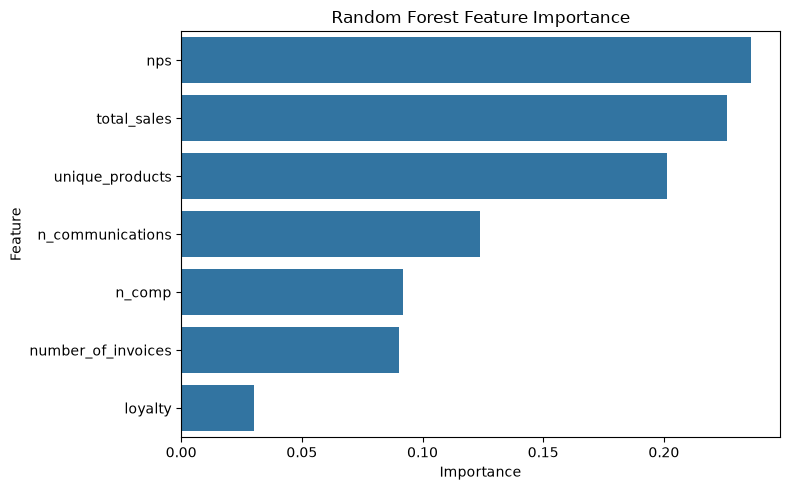

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=rf_feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [32]:
from sklearn.inspection import permutation_importance

In [33]:
rf_permutation = permutation_importance(
    best_random_forest,
    X_test_imputed,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance_Mean": rf_permutation.importances_mean,
    "Importance_Std": rf_permutation.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
)

display(
    permutation_importance_df.round(4)
)

,Feature,Importance_Mean,Importance_Std
3,nps,0.1738,0.0109
5,n_communications,0.0889,0.0131
4,n_comp,0.0805,0.0102
6,loyalty,0.0573,0.0110
0,total_sales,-0.0130,0.0060
1,unique_products,-0.0154,0.0094
2,number_of_invoices,-0.0217,0.0059


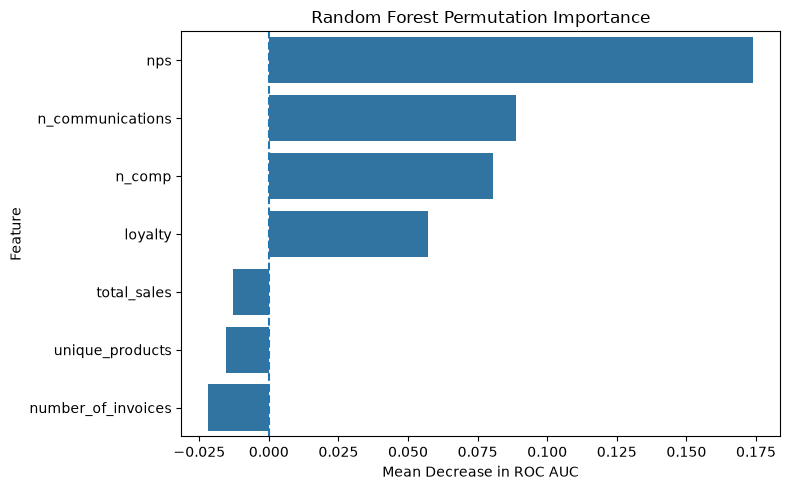

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=permutation_importance_df,
    x="Importance_Mean",
    y="Feature"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Random Forest Permutation Importance")
plt.xlabel("Mean Decrease in ROC AUC")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

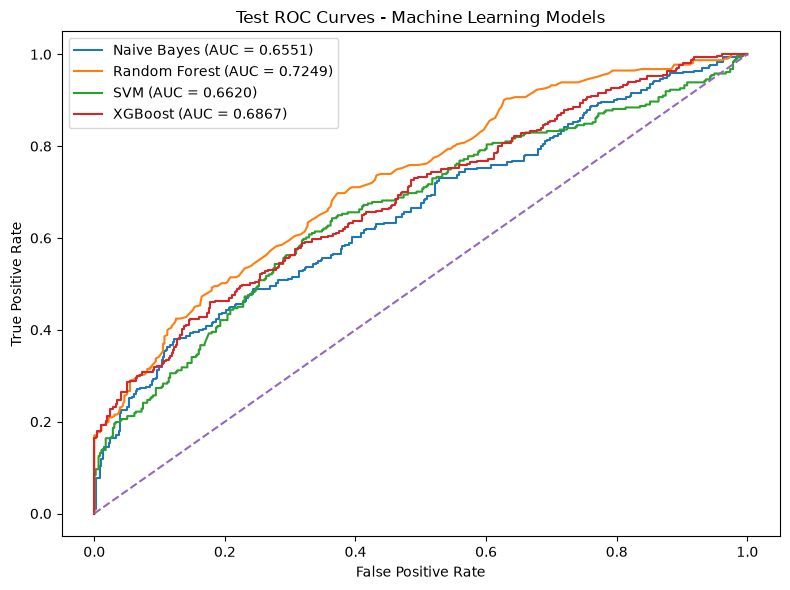

In [35]:
fpr_nb, tpr_nb, _ = roc_curve(
    y_test,
    test_probabilities_nb
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    test_probabilities_rf
)

fpr_svm, tpr_svm, _ = roc_curve(
    y_test,
    test_probabilities_svm
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    test_probabilities_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f"Naive Bayes (AUC = {test_auc_nb:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {test_auc_rf:.4f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {test_auc_svm:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {test_auc_xgb:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curves - Machine Learning Models")
plt.legend()

plt.tight_layout()
plt.show()

<b> Machine Learning Model Findings </b>

-- Four machine learning models were trained to predict campaign response:<br>
Naive Bayes, Random Forest, SVM and XGBoost.

-- The same 80/20 train and test split was used for all models to make<br>
the comparison between the models fair.

-- Missing NPS values were filled using the median calculated only from<br>
the training data to avoid data leakage.

-- StandardScaler was used for the SVM because this model is sensitive<br>
to differences in the scale of the input variables.

-- Naive Bayes achieved a test ROC AUC of 0.6551, while the SVM achieved<br>
a slightly higher test ROC AUC of 0.6620.

-- XGBoost performed better, with a test ROC AUC of 0.6867, but there<br>
was still a noticeable difference between training and test performance.

-- Random Forest achieved the best test ROC AUC of 0.7249 and also had<br>
the highest balanced accuracy among the four models.

-- The Random Forest training ROC AUC was 1.0000, which showed that the<br>
model was overfitting the training data.

-- GridSearchCV with 5-fold Stratified Cross-Validation was used to tune<br>
the Random Forest using only the training data.

-- The best cross-validation ROC AUC was 0.7664 and the selected model<br>
used 300 trees with no maximum depth restriction.

-- Simpler Random Forest models with limited tree depth were also checked,<br>
but they produced lower cross-validation ROC AUC scores.

-- Random Forest was therefore kept as the best model, while the training<br>
overfitting was noted as a limitation.

-- Permutation Importance showed that NPS was the most useful predictor,<br>
followed by communications, complaints and loyalty.

-- Total sales, unique products and number of invoices had negative<br>
permutation importance, suggesting that they added little useful signal<br>
to predictions on unseen data.